# Air Quality Data Analysis
## Section 1: Data Cleaning
### 1. Identifying Issues

- Essential Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

- Importing Data

In [2]:

# Loading the dataset
file = pd.read_csv('air_quality_data.csv')
data = file.copy()



- Identify and document any missing values, outliers, or inconsistencies in the dataset.

In [3]:

# Examine the structure
print(f"\nThe Information about the DataSet {data.info()}")
print(f"\n\n\nDescribing the DataSet {data.describe()}")


 
# Checking & summing all the missing values
missing_values = data.isnull().sum()
print(f"\nMissing values per column: \n{missing_values}")



# Checking for duplicates and summing them
duplicate_count = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


# Check for unrealistic values (negative pollutant levels)
negative_pollutants = data[(data['PM2.5'] < 0) | (data['PM10'] < 0) | (data['SO2'] < 0) | (data['NO2'] < 0) | (data['CO'] < 0) | (data['O3'] < 0)]
print(f"Number of rows with negative pollutant values: {len(negative_pollutants)}")


# Check for unrealistic weather data
unrealistic_weather = data[(data['TEMP'] < -50) | (data['TEMP'] > 50) | ( data['PRES'] < 800) | (data['PRES'] > 1100) | (data['WSPM'] < 0) | (data['WSPM'] > 100)]
print(f"Number of rows with unrealistic weather values: {len(unrealistic_weather)}")



# Identify outliers using IQR method for each pollutant
def identify_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
for pollutant in pollutants:
    outlier_count = identify_outliers(data, pollutant)
    print(f"Number of outliers in {pollutant}: {outlier_count}")


print("\n\n\n\n\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB

The Information about the DataSet None



Describing the DataSet   

### 2. Handling Missing Values and Outliers

##### A ) - Handle missing values using appropriate methods (e.g., mean, median, or interpolation).

In [4]:
# Handle numerical missing values, For numerical columns, fill with median (more robust to outliers than mean)

numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data[col] = data[col].fillna(data[col].median())




# For categorical columns, fill with mode
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:

    # [0] is used to extract the first mode  (most frequent value)
    data[col] = data[col].fillna(data[col].mode()[0])


##### B ) - Handle outliers by either removing or adjusting them.

In [5]:

# Handle outliers using IQR technique. Here: replacing extreme outliers with threshold value.
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    return data



# Cap outliers for pollutant measurements i.e ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
for pollutant in pollutants:
    data = cap_outliers(data, pollutant)



# Handle negative values by replacing with 0
for pollutant in pollutants:
    data[pollutant] = np.where(data[pollutant] < 0, 0, data[pollutant])



# Verify that the data is now clean
print("Missing values after cleaning:")
print(data.isnull().sum())
print("\n\n\n\n\n")

Missing values after cleaning:
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64








##### C ) - Justifying my Approach

## Justification for Data Cleaning Approach

1. **Handling Missing Numerical Values with Median**  
   - The median is used instead of the mean because it is **more robust to outliers**.  
   - The mean can be heavily influenced by extreme values, leading to misleading imputations.  

2. **Handling Missing Categorical Values with Mode**  
   - The mode (most frequent value) ensures that the missing values are replaced with **a realistic category**.  
   - This approach maintains consistency in categorical data without introducing artificial values.  

3. **Outlier Handling Using IQR (Interquartile Range) Capping**  
   - The IQR technique identifies extreme outliers using the **1.5 × IQR rule**, ensuring that unusually high or low values are capped.  
   - Capping outliers preserves the overall distribution while preventing outliers from skewing model performance.  

4. **Replacing Negative Values with 0**  
   - Certain pollutants (e.g., PM2.5, PM10, NO2) cannot have negative concentrations, so negative values are likely errors.  
   - Replacing them with `0` ensures **data integrity** and prevents incorrect interpretations.  

5. **Final Verification of Data Cleanliness**  
   - Checking `data.isnull().sum()` ensures that all missing values have been handled.  
   - This step confirms that the dataset is now ready for further analysis or machine learning modeling.  
    <br>
    <br>
    <br>
    <br>
    <br>
    <br>

## Section 2: Feature Engineering
### 1. Add New Columns

#### A)- Add a new column called air_quality_index

In [6]:
# Add Air Quality Index and Pollution Level
data['air_quality_index'] = (data['PM2.5'] + data['PM10'] + data['NO2'] + data['O3']) / 4
print(data['air_quality_index'].head())
print("\n\n\n\n\n")


0    23.00
1    25.00
2    24.25
3    23.75
4    22.50
Name: air_quality_index, dtype: float64








#### B)- Add a new column called pollution_level

In [7]:

# Categorize pollution levels
def categorize_pollution(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    else:
        return "Unhealthy"

data['pollution_level'] = data['air_quality_index'].apply(categorize_pollution)
print(data['pollution_level'].head())
print("\n\n\n\n\n")

0    Good
1    Good
2    Good
3    Good
4    Good
Name: pollution_level, dtype: object








### 2. Additional Features

#### A)- Create a new column called season

In [8]:
# First, ensure we have a proper datetime column
if 'year' in data.columns and 'month' in data.columns and 'day' in data.columns:
    data['date'] = pd.to_datetime(data[['year', 'month', 'day']])
else:
    # Assuming there's a timestamp column
    data['date'] = pd.to_datetime(data['timestamp'])



# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

data['season'] = data['date'].dt.month.apply(get_season)



#### B)- Create a new column called weekday

In [9]:
# Create weekday column
data['weekday'] = data['date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Display the first few rows with new features
print(data[['date', 'air_quality_index', 'pollution_level', 'season', 'weekday']].head())

print("\n\n\n\n\n")

        date  air_quality_index pollution_level  season  weekday
0 2013-03-01              23.00            Good  Spring  Weekday
1 2013-03-01              25.00            Good  Spring  Weekday
2 2013-03-01              24.25            Good  Spring  Weekday
3 2013-03-01              23.75            Good  Spring  Weekday
4 2013-03-01              22.50            Good  Spring  Weekday








## Section 3: Visualization
### 1. Time-Series Plot of Air Quality Index

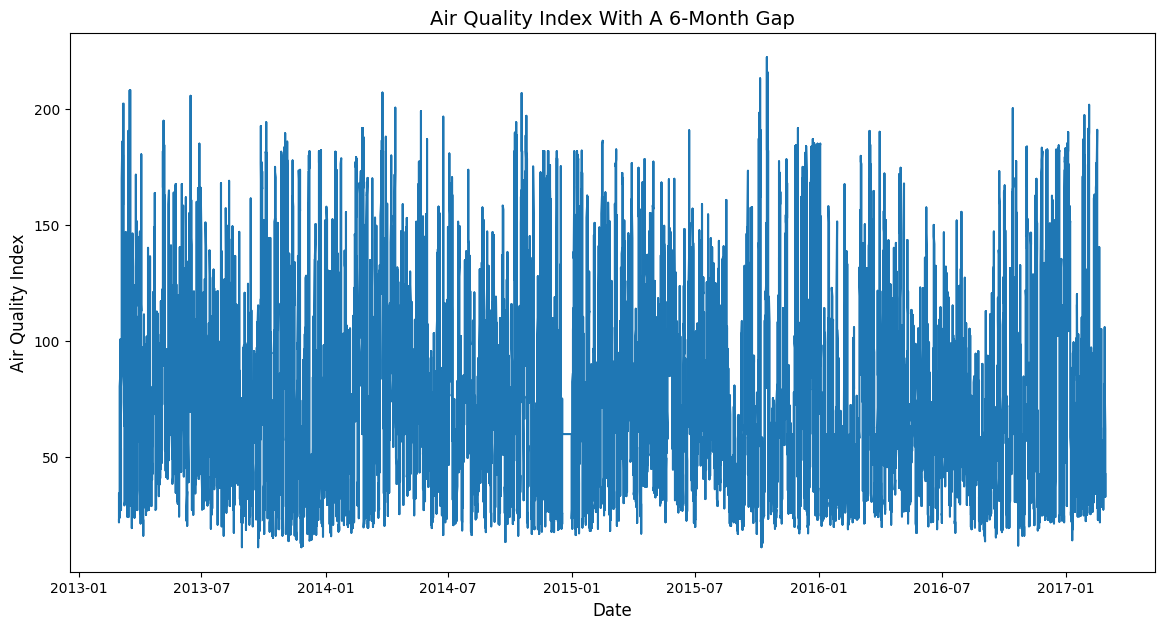

In [10]:
# Figure Size
plt.figure(figsize=(14, 7))


# X and Y Coordinates
plt.plot(data['date'], data['air_quality_index'])


# Title of the Graph
plt.title('Air Quality Index With A 6-Month Gap', fontsize=14)


# Labeling X and Y axis
plt.xlabel('Date', fontsize=12)
plt.ylabel('Air Quality Index', fontsize=12)



plt.show()

## Air Quality Analysis

### High Variability
The AQI fluctuates significantly throughout the dataset, indicating frequent short-term changes in air quality.

### Seasonal Trends
There appear to be recurring spikes in AQI, suggesting possible seasonal pollution patterns. For example:

- **Peaks** may occur during specific times of the year, possibly due to winter pollution, industrial activity, or seasonal weather effects.
- **Some periods** show relatively lower AQI levels, which could correspond to seasons with improved air quality.

### Long-Term Trends
While no clear upward or downward trend is immediately obvious, the density of high AQI values in later years could suggest:

- **Worsening air quality** over time.
- **Changes in measurement sensitivity** that impact AQI readings.

Further statistical analysis, such as seasonal decomposition, rolling averages, or Fourier transformations, could help confirm these patterns.

<br>
<br>
<br>
<br>
<br>

### 2. Pollutant Comparison Across Seasons

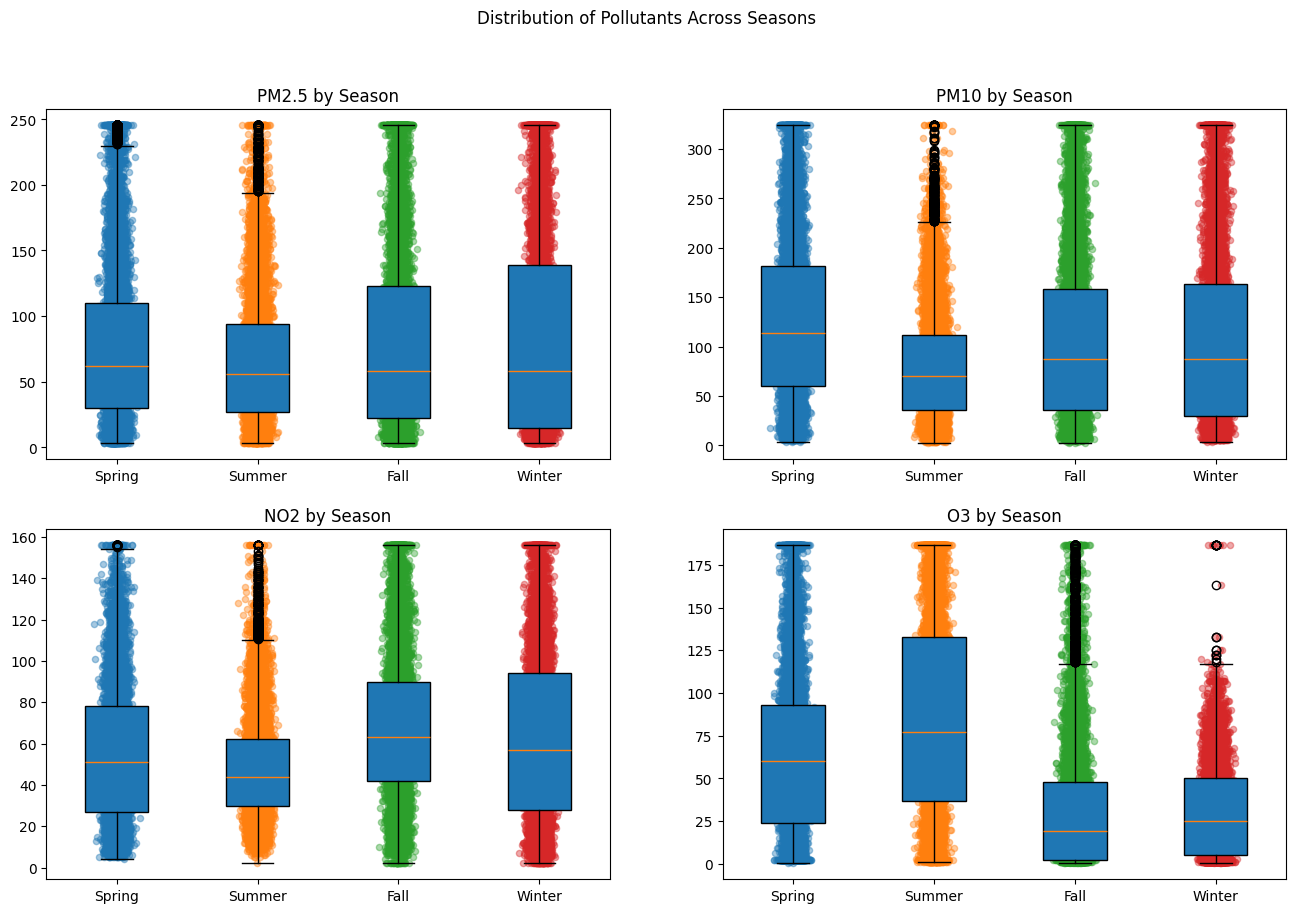

In [11]:
# Creating a figure with a 2x2 grid of subplots and setting the overall figure size
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# Iterating through each pollutant type
for i, pollutant in enumerate(['PM2.5', 'PM10', 'NO2', 'O3']):


    # Extracting seasonal data for the current pollutant
    season_data = [data[data['season'] == season][pollutant] for season in data['season'].unique()]


    # Creating a boxplot for the pollutant across different seasons
    axes.flatten()[i].boxplot(season_data, tick_labels=data['season'].unique(), patch_artist=True)


    # Adding scatter points to show individual data values within each season
    [axes.flatten()[i].scatter(np.random.normal(j+1, 0.04, len(values)), values, alpha=0.4, s=20) 
        for j, values in enumerate(season_data)]
    
    
    # Setting the title for each subplot based on the pollutant name
    axes.flatten()[i].set_title(f'{pollutant} by Season')


# Setting a super title for the entire figure
plt.suptitle('Distribution of Pollutants Across Seasons')

# Displaying the plot
plt.show()


# Insights from the Box Plot

The box plots illustrate the seasonal distribution of four pollutants (PM2.5, PM10, NO2, and O3). Key insights include:

### **1. PM2.5 & PM10**
- Higher concentrations are observed in **Spring and Winter**, while **Summer** shows relatively lower levels.
- The interquartile range (IQR) is similar across seasons, but **Summer has more outliers**.

### **2. NO2**
- **Winter and Fall** exhibit higher median concentrations than Summer.
- This indicates increased pollution in colder months, likely due to **lower dispersion and increased emissions** from heating sources.

### **3. O3**
- The highest median values appear in **Summer**.
- This suggests that ozone levels peak during warmer months due to **increased photochemical reactions** driven by sunlight.

### **Conclusion**
- **Particulate pollutants (PM2.5, PM10, NO2) tend to be higher in colder seasons**.
- **Ozone (O3) peaks in warmer months**, aligning with expected seasonal variations in air pollution.
<br>
<br>
<br>
<br>
<br>

### 3. Temperature vs Air Quality Index

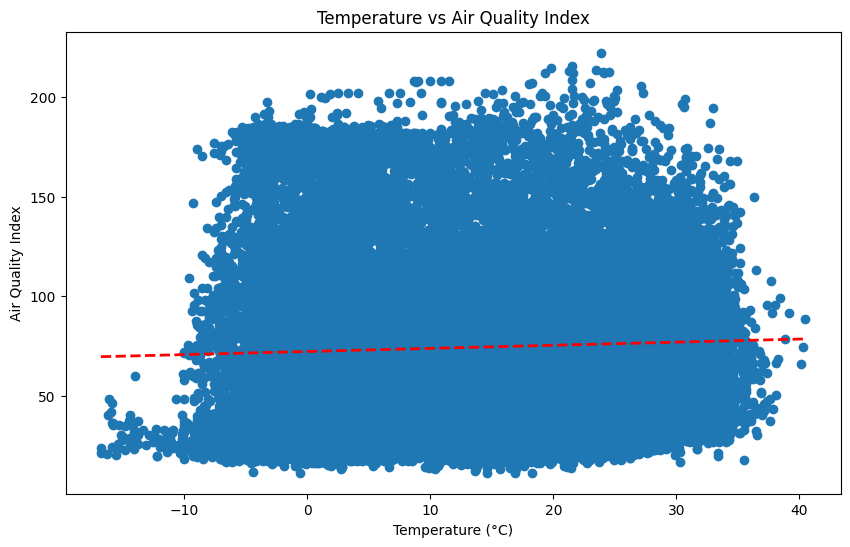

In [12]:
# Creating a figure with a specified size
plt.figure(figsize=(10, 6))

# Creating a scatter plot of temperature vs air quality index with transparency
plt.scatter(data['TEMP'], data['air_quality_index'])


# Calculating the linear trend line for temperature and AQI
trend = np.polyfit(data['TEMP'], data['air_quality_index'], 1)


# Plotting the trend line using a dashed red line with a specified width
plt.plot(np.sort(data['TEMP']), np.poly1d(trend)(np.sort(data['TEMP'])), 'r--', linewidth=2)


# Setting the title and axis labels
plt.title('Temperature vs Air Quality Index')
plt.xlabel('Temperature (°C)')
plt.ylabel('Air Quality Index')



# Displaying the plot
plt.show()


# Relationship Between Temperature and Air Quality Index

The scatter plot illustrates the relationship between **Temperature (°C) and Air Quality Index (AQI)**. 

### **Observations:**
- The data points appear **widely dispersed**, indicating **high variability** in AQI across different temperatures.
- The red dashed line represents the **linear trend**, which shows a **slight positive correlation** between temperature and AQI.
- This suggests that **as temperature increases, AQI tends to increase slightly**, but the correlation is weak.

### **Possible Interpretation:**
- **Higher temperatures** might contribute to increased pollutant levels due to factors like photochemical reactions (e.g., ozone formation).
- However, the **high spread of data points** suggests that **temperature alone is not a strong determinant** of AQI; other factors like wind, humidity, and emissions likely play a significant role.
<br>
<br>
<br>
<br>
<br>

### 4. Pollution Level Analysis

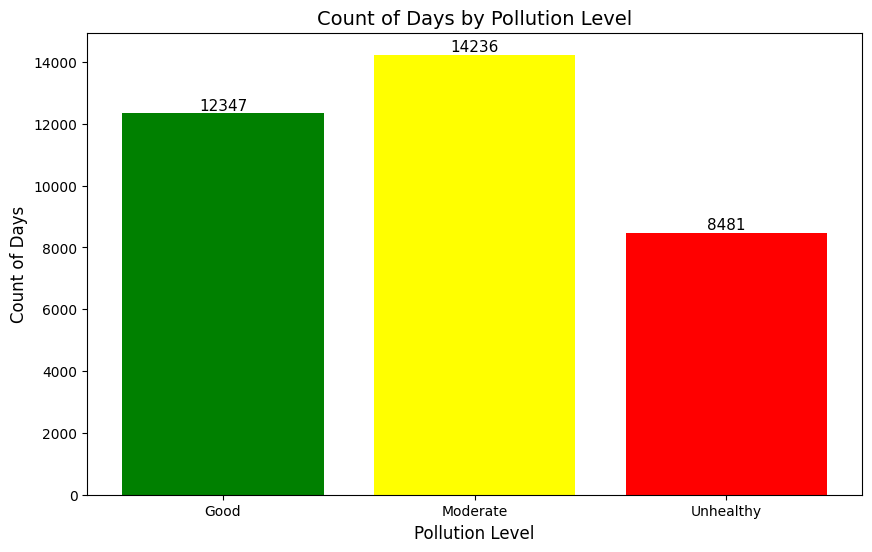

In [13]:
plt.figure(figsize=(10, 6))


# Count occurrences of each pollution level and reorders them to ensure the order is ['Good', 'Moderate', 'Unhealthy'], even if some levels are missing (they will appear as NaN).
pollution_counts = data['pollution_level'].value_counts().reindex(['Good', 'Moderate', 'Unhealthy'])


# Create bar chart
bars = plt.bar(pollution_counts.index, pollution_counts.values, color=['green', 'yellow', 'red'])


plt.title('Count of Days by Pollution Level', fontsize=14)
plt.xlabel('Pollution Level', fontsize=12)
plt.ylabel('Count of Days', fontsize=12)


# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}', ha='center', va='bottom', fontsize=11)


plt.show()

# Insights from the Bar Plot: Count of Days by Pollution Level

The bar plot represents the count of days categorized into three pollution levels: **Good, Moderate, and Unhealthy**.

### **Observations:**
- **Moderate pollution days are the most frequent (14,236 days)**, indicating that air quality is often neither very poor nor very clean.
- **Good air quality days (12,347 days)** occur less frequently than moderate days but still make up a significant portion.
- **Unhealthy air quality days (8,481 days)** are the least frequent, but their presence suggests a notable number of days with poor air quality.

### **Key Insights:**
- While a majority of days fall within the **Moderate and Good categories**, a substantial number of days still experience **Unhealthy air quality**, which could pose risks to public health.
- Efforts to reduce pollution levels could focus on decreasing the number of **Unhealthy days** and shifting more days from **Moderate to Good** air quality.
<br>
<br>
<br>
<br>
<br>

### 5. Monthly Air Quality Patterns

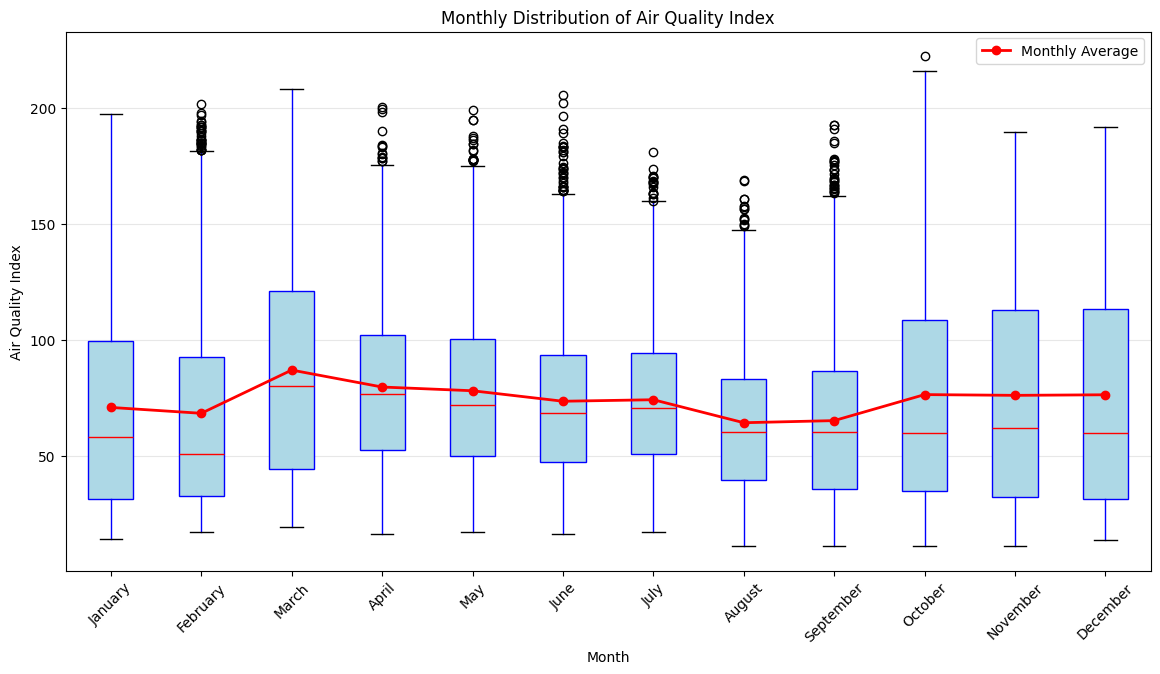

In [14]:
# Creating a figure with a specified size
plt.figure(figsize=(14, 7))


# Extracting air quality index data for each month
month_data = [data[data['date'].dt.month == month]['air_quality_index'] for month in range(1, 13)]


# Getting the month names while ensuring non-empty data for proper labeling
month_names = [data[data['date'].dt.month == month]['date'].dt.month_name().iloc[0] for month in range(1, 13) if not data[data['date'].dt.month == month].empty]

# Creating a boxplot for the air quality index distribution across months
plt.boxplot([m for m in month_data if not m.empty], tick_labels=month_names, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            whiskerprops=dict(color='blue'),
            medianprops=dict(color='red'))

# Setting the title and axis labels
plt.title('Monthly Distribution of Air Quality Index')
plt.xlabel('Month')
plt.ylabel('Air Quality Index')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adding a grid on the y-axis with slight transparency
plt.grid(axis='y', alpha=0.3)

# Calculating and plotting the monthly average air quality index
monthly_avgs = [m.mean() for m in month_data if not m.empty]
plt.plot(range(1, len(monthly_avgs) + 1), monthly_avgs, 'ro-', linewidth=2, markersize=6, label='Monthly Average')

# Adding a legend for the average line
plt.legend()


# Displaying the plot
plt.show()

# Monthly Distribution of Air Quality Index: Patterns and Anomalies

The box plot illustrates the monthly distribution of the **Air Quality Index (AQI)** across the year, with the red line representing the **monthly average AQI**.

### **Repeated Patterns:**
- **Seasonal Trends:** 
  - The **highest AQI values tend to occur in colder months (October to March)**, indicating a potential link between **air pollution and winter conditions** (e.g., increased heating, lower dispersion rates).
  - The **lower AQI values are seen in warmer months (June to August)**, suggesting that **summer conditions improve air quality** due to better dispersion and fewer pollution sources.

- **Consistent Outliers:** 
  - Outliers are present in **most months**, with notable spikes in **March, June, October, and December**.
  - These outliers indicate occasional days with extremely poor air quality, possibly due to specific pollution events like **wildfires, industrial emissions, or weather conditions**.

### **Anomalies and Noteworthy Insights:**
- **March and October exhibit higher median AQI values**, showing periods of **higher pollution levels** that might be due to seasonal activities (e.g., agricultural burning, changes in wind patterns).
- **Despite lower overall AQI in summer (June-August), outliers remain frequent**, implying that some days still experience high pollution levels.
- The **highest recorded AQI values are in December and October**, suggesting that these months have more extreme pollution days.

### **Conclusion:**
- The **winter months show consistently poorer air quality**, likely due to seasonal emissions and stagnant air.
- While summer improves overall AQI, some high-pollution days persist, likely from **localized pollution sources**.
- Monitoring seasonal variations can help develop targeted **pollution control strategies**, especially in peak pollution months.

